# Анализ прямой задачи

В формулы подставляется и варьруется величина волнового числа $k = \omega\sqrt{\mu_0\mu\epsilon_0\epsilon}$ и толщины слоя $h$.

Известно, что $$c = \frac{1}{\sqrt{\mu_0\epsilon_0}}$$, тогда получаем, что $$k = \frac{\omega}{c}\sqrt{\mu\epsilon}$$, где $$\omega - \text{круговая частота}$$ $$c - \text{скорость света}$$ $$\mu,\epsilon - \text{относительная магнитная и диэлектрическая проницаемость среды}$$

Тогда $k_0 = \frac{\omega}{c} = \frac{2\pi}{\lambda_0}$ - волновое чсило вакуума, а $n = \sqrt{\mu\epsilon}$ - показатель преломления.

Для исследования некорректности обратной задачи зафиксируем длину волны $\lambda_0$ в коде и будем вычислять остальные величины как: $$k_0 = \frac{2\pi}{\lambda_0}$$ $$\tilde{h} = k_0h$$ $$\tilde{k}=\frac{k}{k_0} = n_i$$

То есть $k = n_ik_0$, а $\tilde{h}=k_0h$ - безразмерные величины

## Import

In [49]:
import numpy as np
import matplotlib.pyplot as plt
from physics import *

## Forward graphs

In [50]:
theta0 = np.deg2rad(30)

lambda0 = 2 * np.pi # Длина волны в метрах
k0 = 2 * np.pi / lambda0

n1 = 1.0 # воздух
n2 = 1.0 # подложка

h_base = 0.5 # толщина слоя в метрах
theta0 = np.deg2rad(30) # Угол в радианах

In [51]:
n_vals = np.linspace(0.0, 12.0, 10000) # Показатели преломления материала

r_vals = [r_total(np.array([n1, n, n2]) * k0, h_base, theta0) for n in n_vals] # Посчитанные значения коэфициентов отражения

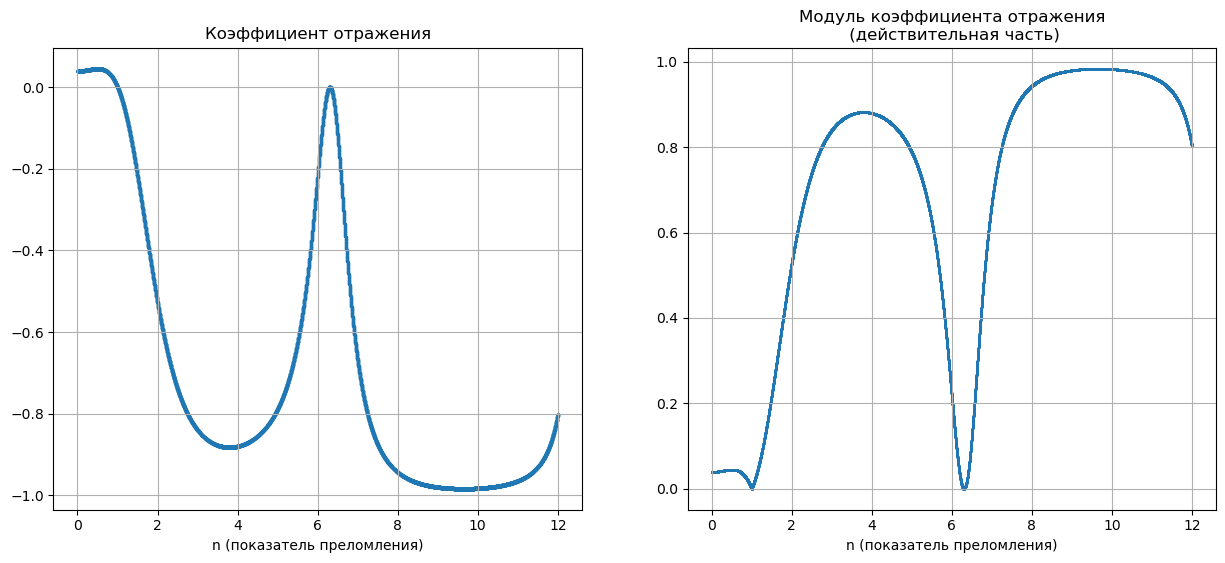

In [52]:
fig, [ax1, ax2] = plt.subplots(1, 2, figsize=(15, 6))

ax1.scatter(n_vals, np.real(r_vals), s=2)
ax1.set_title('Коэффициент отражения')
ax1.set_xlabel('n (показатель преломления)')
ax1.grid()

ax2.scatter(n_vals, np.abs(np.real(r_vals)), s=1)
ax2.set_title('Модуль коэффициента отражения\n (действительная часть)')
ax2.set_xlabel('n (показатель преломления)')
ax2.grid()

На графиках наблюдаются быстрые осцилляции коэффициента отражения как функции показателя преломления. Это означает, что небольшие изменения параметров среды могут приводить к существенным изменениям отраженного сигнала. Следовательно, при наличии шума в измерениях восстановление параметров может оказаться неустойчивым.

In [53]:
print("Максимум |r| =", np.max(np.abs(r_vals)))

Максимум |r| = 0.9839617700984582


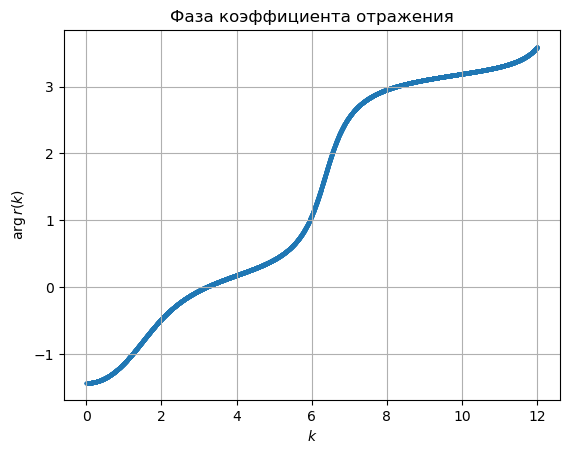

In [54]:
plt.figure()
plt.scatter(n_vals, np.unwrap(np.angle(r_vals), period=np.pi), s=3)
plt.xlabel(r"$k$")
plt.ylabel(r"$\arg r(k)$")
plt.title("Фаза коэффициента отражения")
plt.grid()
plt.show()

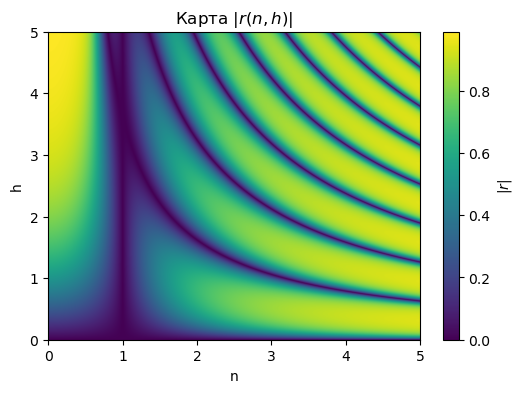

In [55]:
h_vals = np.linspace(0, 5, 1500)
n_vals = np.linspace(0, 5, 1500)

R = r_map(n_vals, h_vals, n1, n2, k0, theta0)

plt.figure(figsize=(6, 4))
plt.imshow(
    np.abs(R),
    origin="lower",
    extent=[n_vals.min(), n_vals.max(), h_vals.min(), h_vals.max()],
    aspect="auto"
)
plt.colorbar(label=r"$|r|$")
plt.xlabel("n")
plt.ylabel("h")
plt.title(r"Карта $|r(n,h)|$")
plt.show()

На этом графике наличие вытянутых долин может говорить о сильной корреляции между $n,h$, то есть изменение одного параметра может компенсироваться изменением второго, при этом давай близкие значения $r$.

Появление семейства долин связано с периодической зависимостью коэффициента отражения от фазового набега. Линии постоянной фазы приблизительно соответствуют условиям фазовый набег=const.

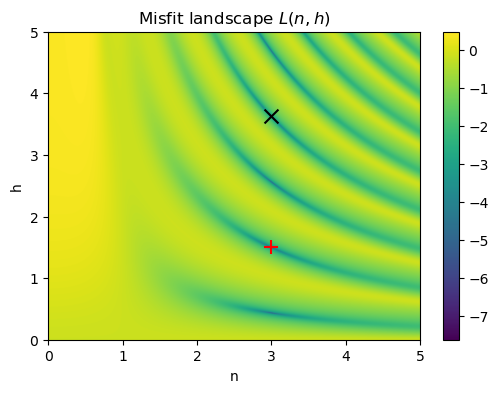

In [56]:
n_true = 3
h_true = 1.5

r_true = r_total(
    np.array([n1, n_true, n2]) * k0,
    h_true,
    theta0
)

R = r_map(n_vals, h_vals, n1, n2, k0, theta0)

loss = np.abs(R - r_true) ** 2
# loss = np.angle(R - r_true)**2

plt.figure(figsize=(6, 4))
plt.imshow(
    np.log10(loss),
    origin="lower",
    extent=[n_vals.min(), n_vals.max(), h_vals.min(), h_vals.max()],
    aspect="auto"
)
plt.colorbar()
plt.xlabel("n")
plt.ylabel("h")
plt.title(r"Misfit landscape $L(n,h)$")
plt.scatter(
    n_true,
    h_true,
    c='red',
    s=100,
    marker='+'
)
idx = np.unravel_index(np.argmin(loss), loss.shape)
plt.scatter(
    n_vals[idx[1]],
    h_vals[idx[0]],
    c='black',
    s=100,
    marker='x'
)
plt.show()

На карте невязки наблюдаются вытянутые долины локальных минимумов. Это означает, что одному и тому же измеренному коэффициенту отражения могут соответствовать различные пары параметров (n,h). Следовательно, обратная задача неоднозначна при использовании данных только для одного угла падения.

In [57]:
def test_multi_on_thetas(thetas, n_true, h_true, n_vals, h_vals, *, noise=False, percent_of_noise=0.05, graphs=False):
    loss = np.zeros((len(n_vals), len(h_vals)), dtype=float)

    mins = []
    areas = []

    for theta in thetas:
        theta = np.deg2rad(theta)

        R_theta = r_map(n_vals, h_vals, n1, n2, k0, theta)

        r_true = r_total(
            np.array([n1, n_true, n2]) * k0,
            h_true,
            theta
        )

        if noise:
            eps_re = np.random.uniform(-percent_of_noise, percent_of_noise)
            eps_im = np.random.uniform(-percent_of_noise, percent_of_noise)
            r_true_noisy = r_true * (1 + eps_re + 1j*eps_im)

            loss += np.abs(R_theta - r_true_noisy)**2
        else:
            loss += np.abs(R_theta - r_true)**2

        idx = np.unravel_index(np.argmin(loss), loss.shape)

        delta = 1e-3
        area = np.sum(loss < loss.min() + delta)

        areas.append(area)
        mins.append(loss.min())

    if graphs:
        plt.figure(figsize=(6, 4))
        plt.imshow(
            np.log10(loss),
            origin="lower",
            extent=[n_vals.min(), n_vals.max(), h_vals.min(), h_vals.max()],
            aspect="auto"
        )
        plt.colorbar()
        plt.xlabel("n")
        plt.ylabel("h")
        plt.title(r"Misfit landscape $L(n,h)$")
        plt.scatter(
            n_true,
            h_true,
            c='red',
            s=100,
            marker='+'
        )
        idx = np.unravel_index(np.argmin(loss), loss.shape)
        plt.scatter(
            n_vals[idx[1]],
            h_vals[idx[0]],
            c='green',
            s=100,
            marker='x'
        )
        plt.show()

    deviation = (
        np.abs(
            np.array([
                n_vals[idx[1]],
                h_vals[idx[0]]
            ]) -
            np.array([
                n_true,
                h_true
            ])
        )
        /
        np.array([
            n_true,
            h_true
        ])
        * 100
    )

    return areas, deviation

In [ ]:
thetas = [10, 30, 45, 60, 85]
# thetas = np.linspace(10, 89, 10)
n_true = 4
h_true = 2
noise_values = np.linspace(0, 0.1, 20)
h_vals = np.linspace(0, 5, 750)
n_vals = np.linspace(0, 5, 750)
deviations = []
areas = []
for noise_value in noise_values:
    area, deviation = test_multi_on_thetas(thetas, n_true, h_true, n_vals, h_vals, graphs=False, noise=True, percent_of_noise=noise_value)
    deviations.append(deviation)
    areas.append(area)

deviations = np.array(deviations)
areas = np.array(areas)

In [64]:
areas

[[5238, 2559, 1341, 850, 832],
 [4961, 2453, 1240, 830, 829],
 [5724, 2664, 1472, 966, 946],
 [5026, 2176, 1359, 963, 980],
 [4134, 1705, 867, 631, 616],
 [6025, 2920, 1730, 1228, 1138],
 [5558, 2396, 1723, 1147, 1134],
 [5408, 1726, 1272, 899, 959],
 [5644, 2245, 925, 827, 814],
 [4218, 1007, 1034, 431, 398],
 [4177, 1403, 1056, 857, 855],
 [4589, 2079, 807, 270, 258],
 [3483, 1306, 694, 476, 424],
 [2936, 1250, 1515, 1311, 1288],
 [3511, 1192, 336, 286, 312],
 [2261, 541, 285, 253, 253],
 [3133, 1685, 369, 892, 970],
 [2267, 911, 433, 288, 272],
 [3681, 375, 166, 470, 540],
 [5628, 818, 550, 868, 834]]

In [60]:
deviations

array([[1.33511348e-01, 2.00267023e-01],
       [6.34178905e-01, 5.34045394e-01],
       [8.01068091e-01, 8.67823765e-01],
       [3.00400534e-01, 2.00267023e-01],
       [8.01068091e-01, 5.34045394e-01],
       [5.70761015e+00, 6.47530040e+00],
       [1.03471295e+00, 4.15220294e+01],
       [9.21228304e+00, 1.01468625e+01],
       [5.34045394e-01, 1.33511348e-01],
       [2.03604806e+00, 4.25233645e+01],
       [1.86915888e+00, 2.46995995e+00],
       [3.87182911e+00, 3.62483311e+01],
       [5.20694259e+00, 3.55807744e+01],
       [4.87316422e+00, 3.72496662e+01],
       [5.34045394e-01, 3.99198932e+01],
       [1.48865154e+01, 7.46328438e+01],
       [1.44859813e+01, 4.65954606e+01],
       [1.12149533e+01, 5.68758344e+01],
       [1.88251001e+01, 1.50000000e+02],
       [1.20493992e+01, 7.73030708e+01]])

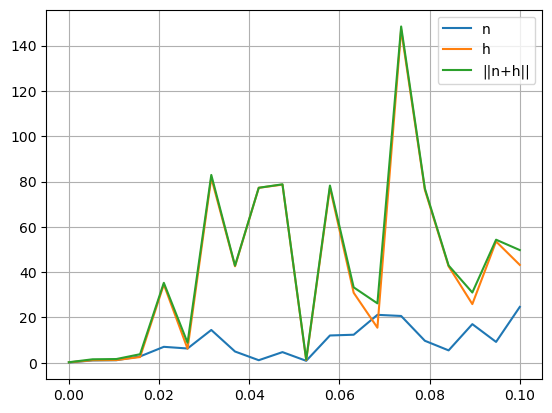

In [84]:
plt.plot(noise_values, deviations[:,0], label="n")
plt.plot(noise_values, deviations[:,1], label="h")
plt.plot(noise_values, np.sqrt(deviations[:,1]**2  + deviations[:, 0]**2), label="||n+h||")
plt.legend()
plt.grid()

На графике относительной погрешности можно видеть, что при увеличении уровня шума, велична ошибки восстановления параметров в среднем растет. То есть задача восстановления `(n, h)` чувствительна к шуму. Однако видно, что растет погрешность некоторыми скачками, что стоит отдельно изучить, но линия нижней тенденции растет.

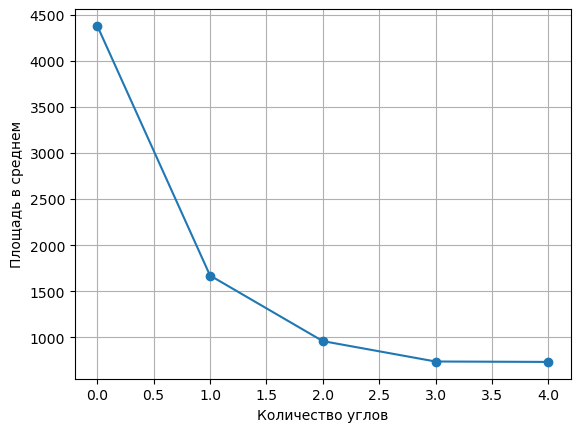

In [79]:
plt.plot(np.average(areas, axis=0), marker='o')
plt.xlabel("Количество углов")
plt.ylabel("Площадь в среднем")
plt.grid()

На этом графике можно наблюдать, что в среднем площадь области минимума начинает уменьшаться с увеличением количества измерений на разных углах.

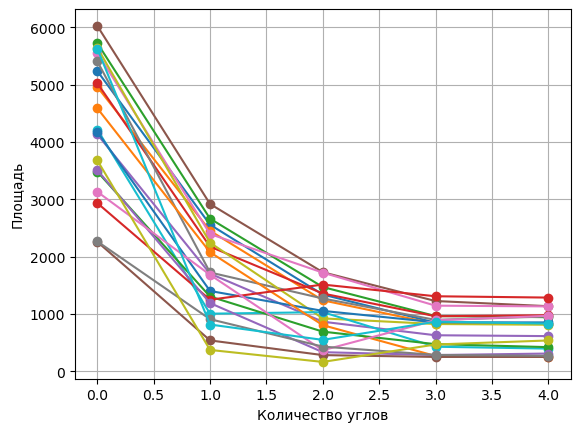

In [78]:
plt.plot(areas.T, marker='o')
plt.xlabel("Количество углов")
plt.ylabel("Площадь")
plt.grid()

На этом графике можно наблюдать, что использование измеренных значений на сетке углов уменьшает области минимумов, что позволяет точнее восстанавливать истинное значение неизвестного параметра.

Анализируя построенные графики, можно сделать вывод о том, что хоть области минимумов невязки уменьшаются по мере увеличения измерений, однако при достаточно большом шуме эта область минимума может оказаться далеко от истинных значений, что говорит о неустойчивости задачи и ее неединственности.

Теперь допустим, что нам известна толщина исследуемого слоя, и попробуем восстановить показанным методом параметр `n` среды.